# Stacking — An Illustrated Tour

> Train several **diverse** base learners, then train a **meta-learner** to combine their predictions. The meta-learner discovers which base model to trust **where**.

---

**What we cover:**
- Architecture: Level-0 (base) → Level-1 (meta)
- The danger of leakage — why we use **out-of-fold** predictions
- Decision boundaries of three diverse bases vs the stacked ensemble
- Side-by-side accuracy comparison
- Stacking vs bagging vs boosting — which to use when

## The picture — diverse base models → meta-learner combines their predictions

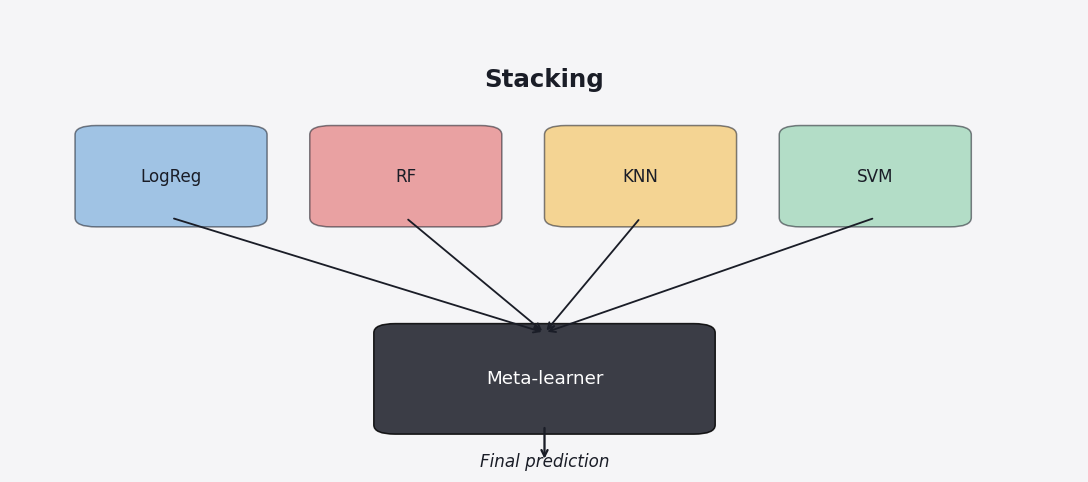

In [1]:
# (schematic — drawn from smooth curves, not measured)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow, FancyBboxPatch, Ellipse, Rectangle, Circle, FancyArrowPatch
plt.rcParams.update({
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'legend.facecolor':'#ffffff','legend.edgecolor':'#c8ccd4','figure.dpi':110,
})
P = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']
fig, ax = plt.subplots(figsize=(10, 4.5)); ax.axis('off')
# Base models row
names = ['LogReg', 'RF', 'KNN', 'SVM']
for i, n in enumerate(names):
    x = 0.15 + i*0.22
    ax.add_patch(FancyBboxPatch((x-0.07, 0.55), 0.14, 0.18, boxstyle='round,pad=0.02',
                                facecolor=P[i % len(P)], edgecolor='#1a1d27', alpha=0.55))
    ax.text(x, 0.64, n, ha='center', va='center', fontsize=11)
    ax.annotate('', xy=(0.5, 0.30), xytext=(x, 0.55),
                arrowprops=dict(arrowstyle='->', color='#1a1d27', lw=1.2))
# Meta-learner
ax.add_patch(FancyBboxPatch((0.36, 0.10), 0.28, 0.20, boxstyle='round,pad=0.02',
                            facecolor='#1a1d27', alpha=0.85))
ax.text(0.5, 0.20, 'Meta-learner', ha='center', va='center', fontsize=12, color='white')
ax.text(0.5, 0.85, 'Stacking', ha='center', va='center', fontsize=16, weight='bold')
ax.text(0.5, 0.02, 'Final prediction', ha='center', va='center', fontsize=11, style='italic')
ax.annotate('', xy=(0.5, 0.02), xytext=(0.5, 0.10),
            arrowprops=dict(arrowstyle='->', color='#1a1d27', lw=1.5))
ax.set_xlim(0, 1); ax.set_ylim(0, 1); plt.tight_layout(); plt.show()


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split, cross_val_score

PLT_STYLE = {
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':17,'axes.labelsize':13,
    'xtick.labelsize':11,'ytick.labelsize':11,'legend.fontsize':11,'legend.facecolor':'#ffffff',
    'legend.edgecolor':'#c8ccd4','figure.dpi':120,
}
plt.rcParams.update(PLT_STYLE)
C0='#5b9bd5'; C1='#e05c5c'; CB='#f4b942'; CM='#7ecba1'; CH='#56b6c2'; CP='#c678dd'

X, y = make_moons(n_samples=200, noise=0.30, random_state=0)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.4, random_state=0)

---
## Architecture

**Level-0 (base learners)** $h_1, h_2, \dots, h_K$ — each trained on the original features. Pick **diverse** algorithms (linear, tree, kNN, neural net, …) so they make different mistakes.

**Level-1 (meta-learner)** $g$ — trained on a new feature vector $\bigl[h_1(x), h_2(x), \dots, h_K(x)\bigr]$ to predict $y$. Usually a simple model (logistic regression / regularised linear) so it can't overfit.

**Out-of-fold (OOF) trick.** If we trained $h_k$ on all of $D$ and fed its predictions on $D$ into the meta-learner, base predictions would be optimistically perfect (they've already seen the labels). To avoid this, we use $K$-fold CV: each fold's predictions are produced by a base model that **didn't see** that fold. `StackingClassifier` does this automatically.

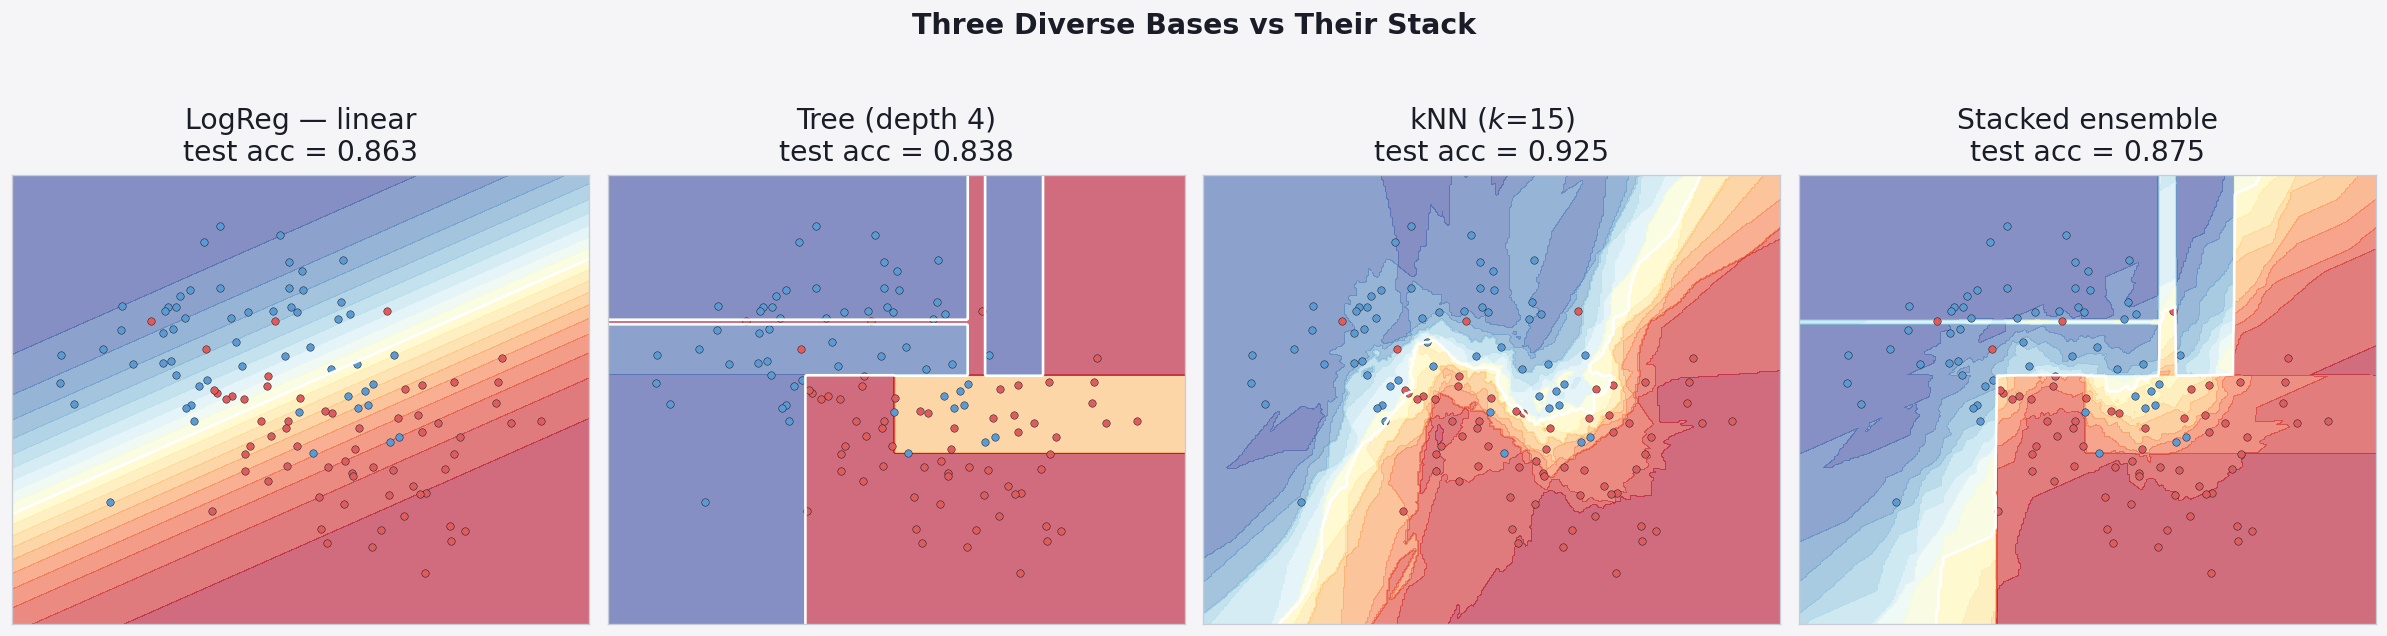

In [3]:
base = [
    ('logreg', LogisticRegression(max_iter=1000)),
    ('tree',   DecisionTreeClassifier(max_depth=4, random_state=0)),
    ('knn',    KNeighborsClassifier(n_neighbors=15)),
]
stack = StackingClassifier(estimators=base,
                            final_estimator=LogisticRegression(),
                            cv=5, passthrough=False).fit(Xtr, ytr)

all_models = base + [('stack', stack)]
fitted = {name: m.fit(Xtr, ytr) for name, m in base}
fitted['stack'] = stack
titles = ['LogReg — linear', 'Tree (depth 4)', 'kNN ($k$=15)', 'Stacked ensemble']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
xx, yy = np.meshgrid(np.linspace(X[:,0].min()-0.4, X[:,0].max()+0.4, 300),
                     np.linspace(X[:,1].min()-0.4, X[:,1].max()+0.4, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
for ax, (name, _), t in zip(axes, all_models, titles):
    p = fitted[name].predict_proba(grid)[:,1].reshape(xx.shape)
    ax.contourf(xx, yy, p, levels=20, cmap='RdYlBu_r', alpha=0.6)
    ax.contour(xx, yy, p, levels=[0.5], colors='#ffffff', linewidths=1.6)
    ax.scatter(Xtr[ytr==0,0], Xtr[ytr==0,1], c=C0, s=20, edgecolors='#1a1d27', lw=0.3)
    ax.scatter(Xtr[ytr==1,0], Xtr[ytr==1,1], c=C1, s=20, edgecolors='#1a1d27', lw=0.3)
    acc = fitted[name].score(Xte, yte)
    ax.set_title(f'{t}\ntest acc = {acc:.3f}', pad=8)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle('Three Diverse Bases vs Their Stack', fontsize=17, fontweight='bold', y=1.05)
plt.tight_layout(); plt.show()

---
## Looking at the Meta-Learner

The stacked logistic regression learns a **weighted vote**. Its coefficients on $\bigl[p_{\text{LR}},\, p_{\text{Tree}},\, p_{\text{kNN}}\bigr]$ tell us how much each base contributed.

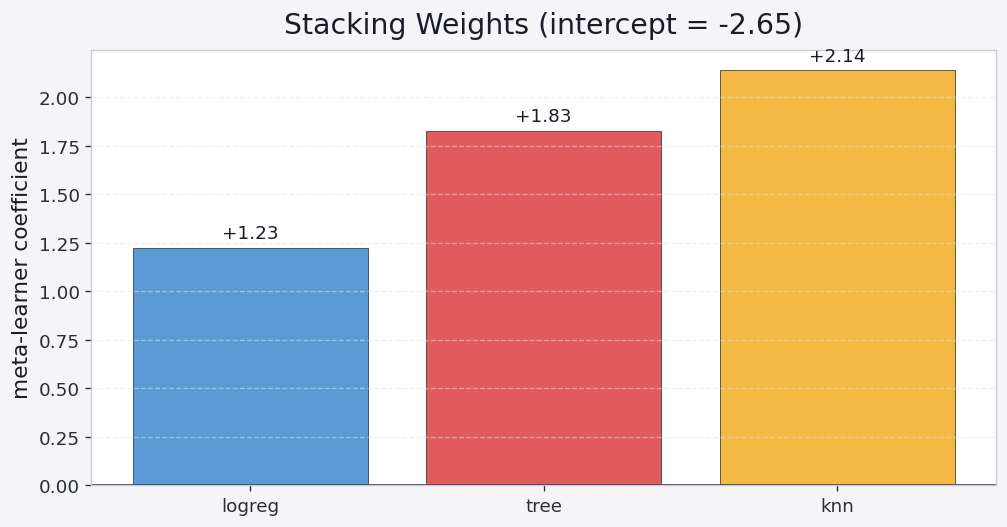

In [4]:
coef = stack.final_estimator_.coef_.ravel()
intercept = stack.final_estimator_.intercept_[0]
names = ['logreg', 'tree', 'knn']
fig, ax = plt.subplots(figsize=(8.5, 4.5))
bars = ax.bar(names, coef, color=[C0, C1, CB], edgecolor='#1a1d27', lw=0.4)
for b, c in zip(bars, coef):
    ax.text(b.get_x()+b.get_width()/2, c + (0.05 if c>=0 else -0.18), f'{c:+.2f}',
            ha='center', color='#1a1d27', fontsize=11)
ax.axhline(0, color='#2a2e3a', lw=1)
ax.set_ylabel('meta-learner coefficient')
ax.set_title(f'Stacking Weights (intercept = {intercept:+.2f})', pad=10)
ax.grid(True, axis='y'); plt.tight_layout(); plt.show()

---
## Cross-Validated Comparison

5-fold CV accuracy on the same data.

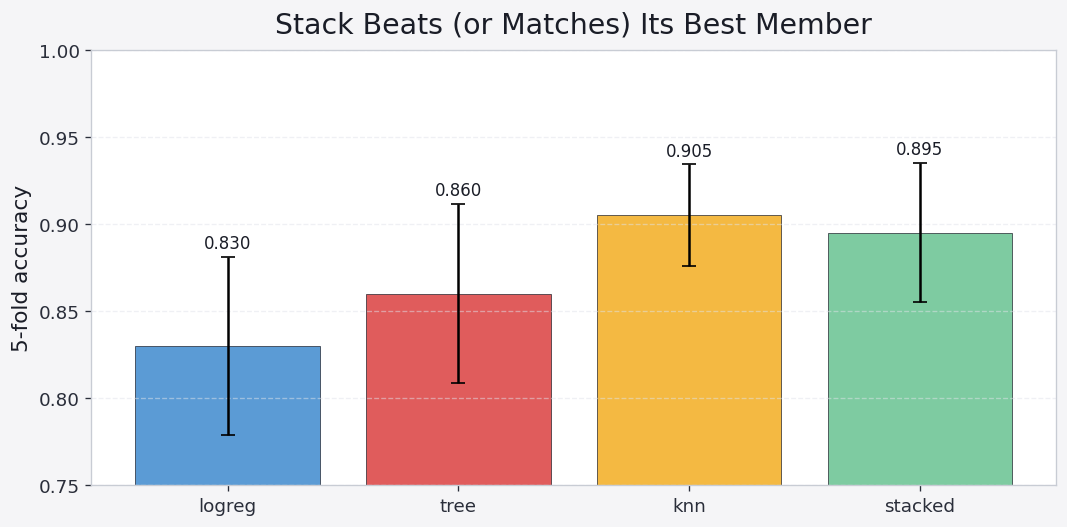

In [5]:
rows = []
for name, m in base:
    s = cross_val_score(m, X, y, cv=5)
    rows.append((name, s.mean(), s.std()))
s = cross_val_score(stack, X, y, cv=5)
rows.append(('stacked', s.mean(), s.std()))

fig, ax = plt.subplots(figsize=(9, 4.5))
names = [r[0] for r in rows]
means = [r[1] for r in rows]
stds  = [r[2] for r in rows]
colors = [C0, C1, CB, CM]
ax.bar(names, means, yerr=stds, color=colors, edgecolor='#1a1d27', lw=0.4, capsize=4)
for x_, m_, s_ in zip(names, means, stds):
    ax.text(x_, m_ + s_ + 0.005, f'{m_:.3f}', ha='center', color='#1a1d27', fontsize=10)
ax.set_ylabel('5-fold accuracy'); ax.set_ylim(0.75, 1.0)
ax.set_title('Stack Beats (or Matches) Its Best Member', pad=10); ax.grid(True, axis='y')
plt.tight_layout(); plt.show()

---
## ⚖️ When to use Stacking — and when not to

| Situation | Stacking | Boosting | Voting | Single tuned model |
|---|---|---|---|---|
| You have several diverse models | ✅ | ❌ | ✅ simpler | ❌ |
| Need last 0.5% accuracy (Kaggle) | ✅ | ✅ | partial | ❌ |
| Limited training time | ❌ many fits | ❌ | ✅ | ✅ |
| Need interpretability | ❌ | ❌ | partial | ✅ |

> Stacking only helps if base models make **different mistakes**. If two of them are highly correlated, drop one.


---
## 🎯 Try this

1. **Diversity matters.** Replace the kNN base learner with a second logistic regression. Stacking gain should shrink — diversity, not count, drives the win.
2. **Out-of-fold leak.** Re-train base learners on the full data (no CV) before training the meta-learner. Test accuracy will *look* great in CV but collapse on a true holdout — observe and explain.
3. **Linear vs non-linear meta.** Replace the logistic meta-learner with a small gradient-boosted model. On most problems the simpler linear blender wins; explain why.


---
## Summary

| Concept | Description | Key Insight |
|---|---|---|
| Level-0 | Diverse base learners | Diversity → different errors to combine |
| Level-1 | Meta-learner on base predictions | Usually simple (logreg) to avoid overfit |
| Out-of-fold | Each base's training set excludes its own predictions | Prevents leakage to meta |
| `passthrough` | Add original features to meta input | Sometimes helps; test it |
| When stacking helps | Heterogeneous bases with non-overlapping errors | Linear/tree/kNN/NN combo is classic |
| Cost | $K$ × base train + meta train | Heavier than bagging or a single boosted model |

**Bagging vs Boosting vs Stacking**
- **Bagging** — same algorithm, different data → lower variance.
- **Boosting** — same algorithm, sequential focus → lower bias.
- **Stacking** — different algorithms, combined by a meta → leverages complementary strengths.

**Bottom line:** Stacking is the **"why pick one?"** ensemble. Train a handful of dissimilar models, let a tiny meta-learner decide who to trust where, and you usually pick up a free 1–2% over the best individual learner.